# Notebook for main analysis of all quantities, except the county-specific analysis
- The Total number and rate of pandemic deaths in each state.
- Point estimates and 95% uncertainty intervals

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt 

from tqdm import tqdm

# Load main functions
import ExcessMortalityFunctions as emf


pathData = 'data/'
pathFigs = 'figures/'

# Load data

In [2]:
df1 = pd.read_csv('data/KY_deaths - v1.csv',parse_dates=[2])
df2 = pd.read_csv('data/MD_deaths - v1.csv',parse_dates=[2])
df1_raw = df1.copy()
df2_raw = df2.copy()

df1.age = df1.age.fillna(-1) # Code missing ages as -1
df2.age = df2.age.fillna(-1) # Code missing ages as -1

In [3]:
dfPop1 = pd.read_csv('data/KY_population - v1.csv')
dfPop2 = pd.read_csv('data/MD_population - v1.csv')

# Restructure data 

In [4]:

serDeaths1 = df1.groupby('date').sum().deaths.copy()
serDeaths2 = df2.groupby('date').sum().deaths.copy()

d1 = np.datetime64('1911-01-01')
d2 = np.datetime64('1930-12-31')
dr = np.arange(d1,d2 + np.timedelta64(1,'D'))
ds = dr[:-1]
dfState = pd.DataFrame(index=dr)
dfState['KY'] = serDeaths1
dfState['MD'] = serDeaths2


d1_KY = serDeaths1.index[0]
d2_KY = serDeaths1.index[-1]
d1_MD = serDeaths2.index[0]
d2_MD = serDeaths2.index[-1]

In [5]:
# Add population, reindex, interpolate and then remove days outside relevant range again
curPop1 = dfPop1.groupby('year').sum()['population']
curPop1.index = pd.to_datetime(curPop1.index,format='%Y')
curPop2 = dfPop2.groupby('year').sum()['population']
curPop2.index = pd.to_datetime(curPop2.index,format='%Y')

dfState['Pop_KY'] = np.nan
dfState['Pop_MD'] = np.nan
for d in curPop1.index:
    dfState.loc[d,'Pop_KY'] = curPop1.loc[d]
    dfState.loc[d,'Pop_MD'] = curPop2.loc[d]

dfState = dfState.reindex(np.arange(dfState.index.min(),dfState.index.max()+np.timedelta64(1,'D'),np.timedelta64(1,'D')))
dfState['Pop_KY'] = dfState['Pop_KY'].interpolate()
dfState['Pop_MD'] = dfState['Pop_MD'].interpolate()

dfState = dfState.loc[d1:d2]

# Set up a function for calculating estimates

In [6]:
numYears = 3 # Baseline based on data from -3 year to +3, i.e. a 6-year baseline
timeResolution = 'Day' # All anaylsis done on daily level and aggregated when necessary

ThresholdToUse = 3 # Zscore threshold to use for data to be omitted from baseline

In [7]:
def mainAnalysisFunction(curData):
    

    # Calculate mean and standard deviation
    curBaseline,curStd = emf.rnMean(curData,numYears=numYears,timeResolution=timeResolution)
    # curExc,curZsc,curExcPct = emf.getExcessAndZscore(curData,curBaseline,curStd)

    # Remove all above threshold
    _,curBaselineFull,curStandardDeviationFull = emf.removeAboveThresholdAndRecalculateRepeatFull(curData,ZscoreThreshold=ThresholdToUse,numYears=numYears,timeResolution=timeResolution)

    # Determine full excess mortality from baseline
    curExcFull,curZscFull,curExcPctFull = emf.getExcessAndZscore(curData,curBaselineFull,curStandardDeviationFull)

    curTime = curBaseline.index 
    curExcess = curData - curBaselineFull
    curZscore = curZscFull

    # Identify all mortality crises.
    dateGroups,allExcess = emf.determineMortalityCrisis(curTime,curExcess,curZscore,upperThreshold=4,lowerThreshold=2,maxDaysBelowThreshold=7,minDurationOfCrisis=0,returnExcessCount=True)
    # dateGroups,allExcess = emf.determineMortalityCrisis(curTime,curExcess,curZscore,upperThreshold=3,lowerThreshold=2,maxDaysBelowThreshold=7,minDurationOfCrisis=0,returnExcessCount=True)
    # dateGroups,allExcess = emf.determineMortalityCrisis(curTime,curExcess,curZscore,upperThreshold=2,lowerThreshold=1,maxDaysBelowThreshold=3,minDurationOfCrisis=0,returnExcessCount=True)

    return dateGroups,allExcess,curBaselineFull,curStandardDeviationFull

In [8]:
def DetermineQuantityOfInterest(curData,dateGroups,curBaselineFull,curStandardDeviationFull):

    # Get start and end date. Just assume its the largest crisis.
    dStart,dEnd = dateGroups[0]
    # print(f'Main crisis goes from {dStart:%Y-%m-%d} to {dEnd:%Y-%m-%d}')
    # print(f'Main crisis goes from {dStart:} to {dEnd:}')

    total_observed = curData.loc[dStart:dEnd].sum()
    total_baseline = curBaselineFull.loc[dStart:dEnd].sum()
    total_baseline_lo = (curBaselineFull + 2 * curStandardDeviationFull).loc[dStart:dEnd].sum()
    total_baseline_hi = (curBaselineFull - 2 * curStandardDeviationFull).loc[dStart:dEnd].sum()

    # print(int(total_observed.round()),int(total_baseline.round()),int(total_baseline_lo.round()),int(total_baseline_hi.round()))

    excess = total_observed - total_baseline
    excess_lo = total_observed - total_baseline_lo
    excess_hi = total_observed - total_baseline_hi

    return excess_lo,excess,excess_hi

# curLower,curEstimate,curUpper = DetermineQuantityOfInterest(curData,dateGroups,curBaseline,curStd)
# np.round(np.array([curLower,curEstimate,curUpper]))

In [9]:
curData_KY = dfState.KY
dateGroups_KY,allExcess_KY,curBaseline_KY,curStd_KY = mainAnalysisFunction(curData_KY)
curLower_KY,curEstimate_KY,curUpper_KY = DetermineQuantityOfInterest(curData_KY,dateGroups_KY,curBaseline_KY,curStd_KY)

In [10]:
curData_MD = dfState.MD.loc[d1_MD:d2_MD]
dateGroups_MD,allExcess_MD,curBaseline_MD,curStd_MD = mainAnalysisFunction(curData_MD)
curLower_MD,curEstimate_MD,curUpper_MD = DetermineQuantityOfInterest(curData_MD,dateGroups_MD,curBaseline_MD,curStd_MD)

In [11]:
print(f'Kentucky: {curEstimate_KY} (95% CI: {curLower_KY} - {curUpper_KY})')
print(f'Maryland: {curEstimate_MD} (95% CI: {curLower_MD} - {curUpper_MD})')

Kentucky: 12794.7 (95% CI: 9406.247712885315 - 16183.152287114684)
Maryland: 4126.733333333334 (95% CI: 3124.8484425042225 - 5128.618224162445)


In [12]:
print(f'Kentucky: {curEstimate_KY:0.0f} (95% CI: {curLower_KY:0.0f}, {curUpper_KY:0.0f})')
print(f'Maryland: {curEstimate_MD:0.0f} (95% CI: {curLower_MD:0.0f}, {curUpper_MD:0.0f})')

Kentucky: 12795 (95% CI: 9406, 16183)
Maryland: 4127 (95% CI: 3125, 5129)


# Also determine rates from estimated population during period

In [13]:
period_KY = dateGroups_KY[0]
popEstimate_KY = dfState.Pop_KY.loc[period_KY[0]:period_KY[1]].mean()
period_MD = dateGroups_MD[0]
popEstimate_MD = dfState.Pop_MD.loc[period_MD[0]:period_MD[1]].mean()

In [14]:
print(f'Kentucky: {curEstimate_KY/popEstimate_KY:0.6f} (95% CI: {curLower_KY/popEstimate_KY:0.6f}, {curUpper_KY/popEstimate_KY:0.6f})')
print(f'Maryland: {curEstimate_MD/popEstimate_MD:0.6f} (95% CI: {curLower_MD/popEstimate_MD:0.6f}, {curUpper_MD/popEstimate_MD:0.6f})')

Kentucky: 0.005322 (95% CI: 0.003913, 0.006732)
Maryland: 0.006931 (95% CI: 0.005249, 0.008614)


In [15]:
print(f'Kentucky period: {period_KY[0]:%Y-%m-%d} to {period_KY[1]:%Y-%m-%d}')
print(f'Maryland period: {period_MD[0]:%Y-%m-%d} to {period_MD[1]:%Y-%m-%d}')

Kentucky period: 1918-09-29 to 1919-02-28
Maryland period: 1918-09-22 to 1919-01-29


# Plot results

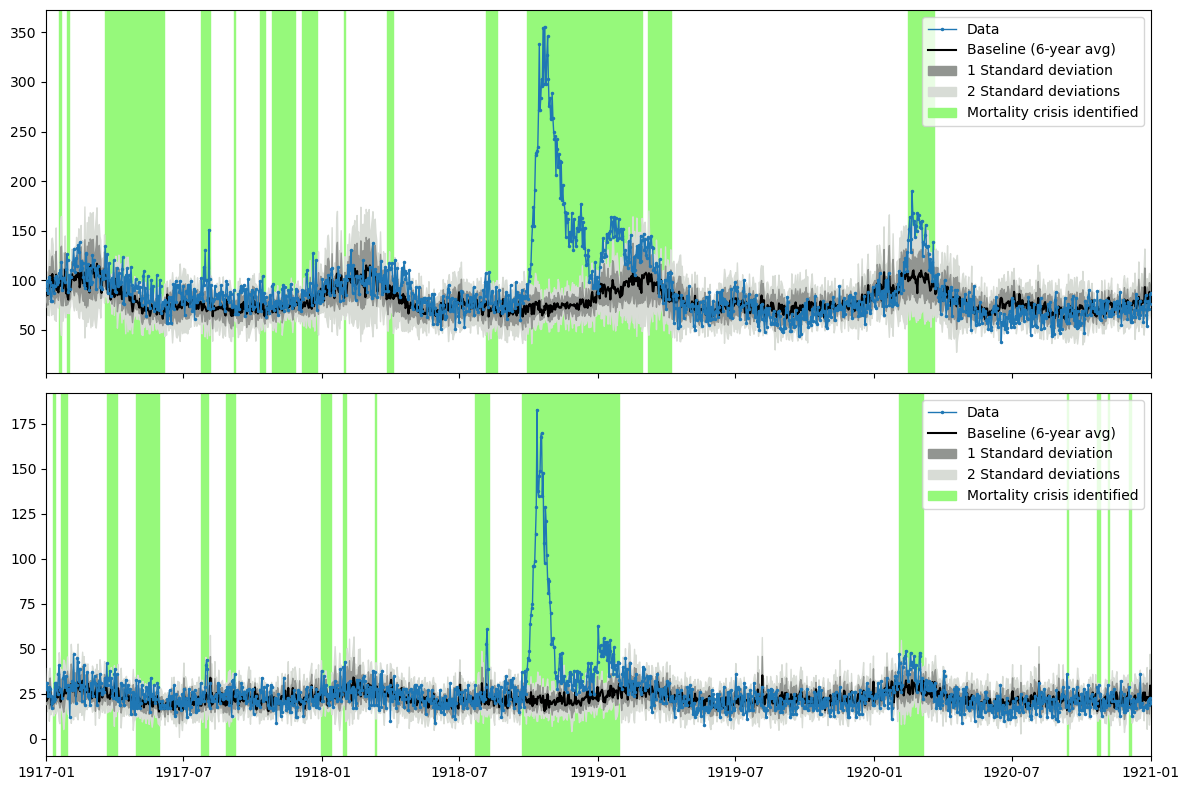

In [16]:
# fig,ax = plt.subplots(figsize=(12,5))
fig,(ax,ax2) = plt.subplots(2,1,figsize=(12,8),sharex=True)

ax.plot(curData_KY,'.-',lw=1,ms=3,zorder=5,label='Data')
ax.plot(curBaseline_KY,'k',zorder=4,label=f'Baseline ({2*numYears}-year avg)')
ax.fill_between(curBaseline_KY.index,
                curBaseline_KY - curStd_KY,
                curBaseline_KY + curStd_KY,
                color='xkcd:gray',
                zorder=3,
                label='1 Standard deviation'
                )
ax.fill_between(curBaseline_KY.index,
                curBaseline_KY - 2 * curStd_KY,
                curBaseline_KY + 2 * curStd_KY,
                color='xkcd:light gray',
                zorder=2,
                label='2 Standard deviations'
                )

for i in range(len(dateGroups_KY)):
    curTotalExcess = allExcess_KY[i]
    if (curTotalExcess > 10):
        curDateGroup = dateGroups_KY[i]
        ax.axvspan(curDateGroup[0],curDateGroup[1],color='xkcd:light green',label=(i==0)*'Mortality crisis identified')


ax.legend(loc='upper right') 
# ax.set_xlim(np.datetime64('1918'),np.datetime64('1921'))


ax2.plot(curData_MD,'.-',lw=1,ms=3,zorder=5,label='Data')
ax2.plot(curBaseline_MD,'k',zorder=4,label=f'Baseline ({2*numYears}-year avg)')
ax2.fill_between(curBaseline_MD.index,
                curBaseline_MD - curStd_MD,
                curBaseline_MD + curStd_MD,
                color='xkcd:gray',
                zorder=3,
                label='1 Standard deviation'
                )
ax2.fill_between(curBaseline_MD.index,
                curBaseline_MD - 2 * curStd_MD,
                curBaseline_MD + 2 * curStd_MD,
                color='xkcd:light gray',
                zorder=2,
                label='2 Standard deviations'
                )

for i in range(len(dateGroups_MD)):
    curTotalExcess = allExcess_MD[i]
    if (curTotalExcess > 10):
        curDateGroup = dateGroups_MD[i]
        ax2.axvspan(curDateGroup[0],curDateGroup[1],color='xkcd:light green',label=(i==0)*'Mortality crisis identified')


ax2.legend(loc='upper right') 
ax2.set_xlim(np.datetime64('1917'),np.datetime64('1921'))
fig.tight_layout()

# Quantity 2

First, make a dataframe of all excess deaths during mortality crises, and then aggregate the results by months

In [17]:
dfResults = pd.DataFrame(index=ds)
dfResults['Excess_KY'] = dfState.KY - curBaseline_KY
dfResults['ExcessHi_KY'] = dfState.KY - (curBaseline_KY - 2 * curStd_KY)
dfResults['ExcessLo_KY'] = dfState.KY - (curBaseline_KY + 2 * curStd_KY)
dfResults['Excess_MD'] = dfState.MD - curBaseline_MD
dfResults['ExcessHi_MD'] = dfState.MD - (curBaseline_MD - 2 * curStd_MD)
dfResults['ExcessLo_MD'] = dfState.MD - (curBaseline_MD + 2 * curStd_MD)
# dfResults

dfResults['DuringCrisis_KY'] = 0
dfResults['DuringCrisis_MD'] = 0
dfResults['DuringCrisis_10orMore_KY'] = 0
dfResults['DuringCrisis_10orMore_MD'] = 0

(np.float64(-19358.0), np.float64(-17897.0))

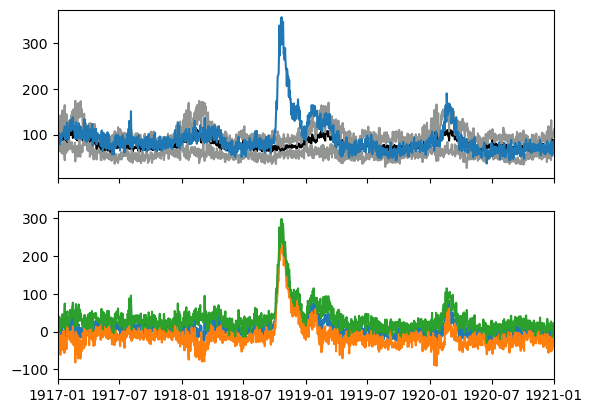

In [18]:
fig,(ax,ax2) = plt.subplots(2,1,sharex=True)
ax.plot(curBaseline_KY,color='k')
ax.plot(curBaseline_KY+2*curStd_KY,color='xkcd:grey')
ax.plot(curBaseline_KY-2*curStd_KY,color='xkcd:grey')

ax.plot(dfState.KY)

ax2.plot(dfResults.Excess_KY)
ax2.plot(dfResults.ExcessLo_KY)
ax2.plot(dfResults.ExcessHi_KY)

ax.set_xlim(np.datetime64('1917'),np.datetime64('1921'))

In [19]:

for i in range(len(dateGroups_KY)):
    curTotalExcess = allExcess_KY[i]
    curDateGroup = dateGroups_KY[i]
    dfResults.loc[curDateGroup[0]:curDateGroup[1],'DuringCrisis_KY'] = 1


for i in range(len(dateGroups_MD)):
    curTotalExcess = allExcess_MD[i]
    curDateGroup = dateGroups_MD[i]
    dfResults.loc[curDateGroup[0]:curDateGroup[1],'DuringCrisis_MD'] = 1

    
for i in range(len(dateGroups_KY)):
    curTotalExcess = allExcess_KY[i]
    if curTotalExcess >= 10:
        curDateGroup = dateGroups_KY[i]
        dfResults.loc[curDateGroup[0]:curDateGroup[1],'DuringCrisis_10orMore_KY'] = 1


for i in range(len(dateGroups_MD)):
    curTotalExcess = allExcess_MD[i]
    if curTotalExcess >= 10:
        curDateGroup = dateGroups_MD[i]
        dfResults.loc[curDateGroup[0]:curDateGroup[1],'DuringCrisis_10orMore_MD'] = 1

In [20]:
dfResults.sum()

Excess_KY                    22544.858333
ExcessHi_KY                 159562.010742
ExcessLo_KY                -114472.294075
Excess_MD                     5550.533333
ExcessHi_MD                  34639.419273
ExcessLo_MD                 -23538.352607
DuringCrisis_KY               1790.000000
DuringCrisis_MD               1130.000000
DuringCrisis_10orMore_KY      1669.000000
DuringCrisis_10orMore_MD       945.000000
dtype: float64

In [21]:
dfResults['ExcessCrisis_KY'] = dfResults.Excess_KY * dfResults.DuringCrisis_KY
dfResults['ExcessLoCrisis_KY'] = dfResults.ExcessLo_KY * dfResults.DuringCrisis_KY
dfResults['ExcessHiCrisis_KY'] = dfResults.ExcessHi_KY * dfResults.DuringCrisis_KY

dfResults['ExcessCrisis_MD'] = dfResults.Excess_MD * dfResults.DuringCrisis_MD
dfResults['ExcessLoCrisis_MD'] = dfResults.ExcessLo_MD * dfResults.DuringCrisis_MD
dfResults['ExcessHiCrisis_MD'] = dfResults.ExcessHi_MD * dfResults.DuringCrisis_MD

toPrint_KY = ['ExcessCrisis_KY','ExcessLoCrisis_KY','ExcessHiCrisis_KY']
toPrint_MD = ['ExcessCrisis_MD','ExcessLoCrisis_MD','ExcessHiCrisis_MD']
display(dfResults.loc[period_KY[0]:period_KY[1],toPrint_KY].sum().round(2))
display(dfResults.loc[period_MD[0]:period_MD[1],toPrint_MD].sum().round(2))

ExcessCrisis_KY      12794.70
ExcessLoCrisis_KY     9406.25
ExcessHiCrisis_KY    16183.15
dtype: float64

ExcessCrisis_MD      4126.73
ExcessLoCrisis_MD    3124.85
ExcessHiCrisis_MD    5128.62
dtype: float64

In [22]:
reportMonth1 = np.datetime64('1918-03')
reportMonth2 = np.datetime64('1921-05')

In [23]:
# dfResults.loc[reportMonth1:reportMonth2,toPrint_KY]
# dfResults.groupby() 
dfResultsMonth = dfResults.groupby(dfResults.index.to_period('M')).sum()
dfResultsMonth.index = dfResultsMonth.index.to_timestamp()
# dfResultsMonth.loc[reportMonth1:reportMonth2].iloc[:,-6:].to_excel('Quantity2_MonthlyExcess.xlsx')

In [24]:
# Determine rates

dfPopMonth = dfState[['Pop_KY','Pop_MD']].groupby(dfState.index.to_period('M')).mean()
dfPopMonth.index = dfPopMonth.index.to_timestamp()
# dfResultsMonthdfPopMonth

dfResultsMonth['ExcessCrisis_KY_PerPop'] = dfResultsMonth['ExcessCrisis_KY'] / dfPopMonth['Pop_KY']
dfResultsMonth['ExcessLoCrisis_KY_PerPop'] = dfResultsMonth['ExcessLoCrisis_KY'] / dfPopMonth['Pop_KY']
dfResultsMonth['ExcessHiCrisis_KY_PerPop'] = dfResultsMonth['ExcessHiCrisis_KY'] / dfPopMonth['Pop_KY']

dfResultsMonth['ExcessCrisis_MD_PerPop'] = dfResultsMonth['ExcessCrisis_MD'] / dfPopMonth['Pop_MD']
dfResultsMonth['ExcessLoCrisis_MD_PerPop'] = dfResultsMonth['ExcessLoCrisis_MD'] / dfPopMonth['Pop_MD']
dfResultsMonth['ExcessHiCrisis_MD_PerPop'] = dfResultsMonth['ExcessHiCrisis_MD'] / dfPopMonth['Pop_MD']


In [25]:
# Save results to excel to make it easier to copy into reporting sheet
dfResultsMonth.loc[reportMonth1:reportMonth2].iloc[:,-12:].to_excel('Quantity2_MonthlyExcess.xlsx')

In [26]:
dfResultsMonth.loc[reportMonth1:reportMonth2].sum()

Excess_KY                   11391.250000
ExcessHi_KY                 38560.832992
ExcessLo_KY                -15778.332992
Excess_MD                    3873.550000
ExcessHi_MD                 14105.987766
ExcessLo_MD                 -6358.887766
DuringCrisis_KY               259.000000
DuringCrisis_MD               204.000000
DuringCrisis_10orMore_KY      244.000000
DuringCrisis_10orMore_MD      195.000000
ExcessCrisis_KY             15166.116667
ExcessLoCrisis_KY            8882.762538
ExcessHiCrisis_KY           21449.470796
ExcessCrisis_MD              4669.650000
ExcessLoCrisis_MD            3023.689772
ExcessHiCrisis_MD            6315.610228
ExcessCrisis_KY_PerPop          0.006307
ExcessLoCrisis_KY_PerPop        0.003697
ExcessHiCrisis_KY_PerPop        0.008916
ExcessCrisis_MD_PerPop          0.007840
ExcessLoCrisis_MD_PerPop        0.005080
ExcessHiCrisis_MD_PerPop        0.010601
dtype: float64

# Quantity 3
Estimates by five-year agegroups

Poisson distribution rather than normal

Sum of estimate during same pandemic period as determined from mortality of all agegroups (rather than agegroup-specific mortality crisis).

In [33]:
dfAge_KY = df1.groupby(['date','age']).deaths.sum().reset_index().pivot_table(columns='age',index='date',values='deaths')
dfAge_KY = dfAge_KY.reindex(dr) # Ensure that all dates are included

dfAge_KY = dfAge_KY.T 
dfAge_KY = dfAge_KY.reindex(np.arange(-1,np.max(dfAge_KY.index)+1)) # Ensure that all ages are included
dfAge_KY = dfAge_KY.T
dfAge_KY = dfAge_KY.fillna(0) # Fill missing values with zeros


# Group by five-year-intervals
ageGroups = np.arange(0,dfAge_KY.columns[-1]+1,5)
dfAgeGrouped_KY = pd.DataFrame(index=dfAge_KY.index)

for i,minAge in enumerate(ageGroups):
    maxAge = minAge + 4
    minAge = int(minAge)
    maxAge = int(maxAge)
    dfAgeGrouped_KY[minAge] = dfAge_KY.loc[:,minAge:maxAge].sum(axis=1)


In [ ]:
# Same thing, but with MD
dfAge_MD = df2.groupby(['date','age']).deaths.sum().reset_index().pivot_table(columns='age',index='date',values='deaths')
dfAge_MD = dfAge_MD.reindex(dr) # Ensure that all dates are included

dfAge_MD = dfAge_MD.T 
dfAge_MD = dfAge_MD.reindex(np.arange(-1,np.max(dfAge_MD.index)+1)) # Ensure that all ages are included
dfAge_MD = dfAge_MD.T
dfAge_MD = dfAge_MD.fillna(0) # Fill missing values with zeros

# Group by five-year-intervals
ageGroups = np.arange(0,dfAge_MD.columns[-1]+1,5)
dfAgeGrouped_MD = pd.DataFrame(index=dfAge_MD.index)

for i,minAge in enumerate(ageGroups):
    maxAge = minAge + 4
    minAge = int(minAge)
    maxAge = int(maxAge)
    dfAgeGrouped_MD[minAge] = dfAge_MD.loc[:,minAge:maxAge].sum(axis=1)

### Test-analysis and test-plot of a single agegroup

In [59]:
curSer = dfAgeGrouped_KY[60]
curSer = dfAgeGrouped_KY[20]
# curSer = dfAgeGrouped_KY[0]
# Determine first baseline
curBaseline,curSF = emf.rnMean(curSer,numYears=numYears,timeResolution=timeResolution,distributionType='Poisson')
# Remove all above threshold
_,curBaselineFull,curSFFull = emf.removeAboveThresholdAndRecalculateRepeatFull(curSer,ZscoreThreshold=ThresholdToUse,numYears=numYears,timeResolution=timeResolution,distributionType='Poisson')

# Get confidence intervals
intervalValue = 0.95
curBot,curTop = emf.getPoissonIntervals(intervalValue,curBaselineFull)

# Calculate excess (as well as uncertainty intervals)
curExcess = curSer - curBaselineFull
curExcessHi = curSer - curBot
curExcessLo = curSer - curTop 


(0.0, 37.485)

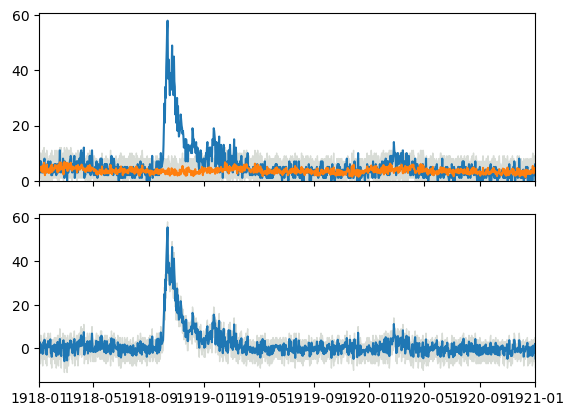

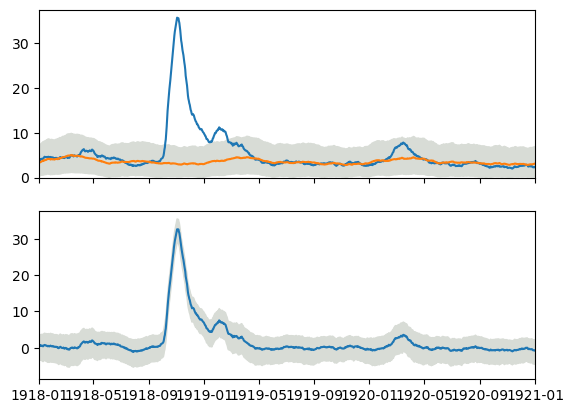

In [61]:
fig,(ax,ax2) = plt.subplots(2,1,sharex=True)
ax.plot(curSer)
ax.plot(curBaselineFull)
ax.fill_between(curExcess.index,curBot,curTop,color='xkcd:light grey')

ax2.plot(curExcess)
ax2.fill_between(curExcess.index,curExcessLo,curExcessHi,color='xkcd:light grey')

ax.set_ylim(0)
ax.set_xlim(np.datetime64('1918'),np.datetime64('1921'))
# ax.set_xlim(np.datetime64('1919'),np.datetime64('1920'))

fig,(ax,ax2) = plt.subplots(2,1,sharex=True)

ax.plot(curSer.rolling(window=30).mean())
ax.plot(curBaselineFull.rolling(window=30).mean())
ax.fill_between(curExcess.index,curBot.rolling(window=30).mean(),curTop.rolling(window=30).mean(),color='xkcd:light grey')

ax2.plot(curExcess.rolling(window=30).mean())
ax2.fill_between(curExcess.index,curExcessLo.rolling(window=30).mean(),curExcessHi.rolling(window=30).mean(),color='xkcd:light grey')

ax.set_xlim(np.datetime64('1918'),np.datetime64('1921'))
# ax.set_xlim(np.datetime64('1919'),np.datetime64('1920'))

ax.set_ylim(0)

### Analyse all agegroups

In [62]:
def funcCalcEstimatesPoisson(curSer):
        
    # # Determine first baseline
    # curBaseline,curSF = emf.rnMean(curSer,numYears=numYears,timeResolution=timeResolution,distributionType='Poisson')
    # Remove all above threshold
    _,curBaselineFull,curSFFull = emf.removeAboveThresholdAndRecalculateRepeatFull(curSer,ZscoreThreshold=ThresholdToUse,numYears=numYears,timeResolution=timeResolution,distributionType='Poisson')

    # Get confidence intervals
    intervalValue = 0.95
    curBot,curTop = emf.getPoissonIntervals(intervalValue,curBaselineFull)

    # Calculate excess (as well as uncertainty intervals)
    curExcess = curSer - curBaselineFull
    curExcessHi = curSer - curBot
    curExcessLo = curSer - curTop 

    return curExcess,curExcessLo,curExcessHi

# curExcess,curExcessLo,curExcessHi = funcCalcEstimatesPoisson(dfAgeGrouped_KY.loc[:,50])


In [63]:
# Go through all ages
dfAgeResults = pd.DataFrame(index=dfAgeGrouped_KY.columns)
dfAgeResults['Estimate_KY'] = np.nan
dfAgeResults['Lower_KY'] = np.nan
dfAgeResults['Higher_KY'] = np.nan


for col in tqdm(dfAgeGrouped_KY.columns):
    curSer = dfAgeGrouped_KY[col]

    curExcess,curExcessLo,curExcessHi = funcCalcEstimatesPoisson(curSer)

    periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum()
    periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum()
    periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum()
    
    dfAgeResults.loc[col,'Estimate_KY'] = periodExcess
    dfAgeResults.loc[col,'Lower_KY'] = periodExcessLo
    dfAgeResults.loc[col,'Higher_KY'] = periodExcessHi

  0%|          | 0/19 [00:00<?, ?it/s]

100%|██████████| 19/19 [00:09<00:00,  2.09it/s]


In [64]:
# Same thing with MD
dfAgeResults['Estimate_MD'] = np.nan
dfAgeResults['Lower_MD'] = np.nan
dfAgeResults['Higher_MD'] = np.nan


for col in tqdm(dfAgeGrouped_MD.columns):
    curSer = dfAgeGrouped_MD[col]

    curExcess,curExcessLo,curExcessHi = funcCalcEstimatesPoisson(curSer)

    periodExcess = curExcess.loc[period_MD[0]:period_MD[1]].sum()
    periodExcessLo = curExcessLo.loc[period_MD[0]:period_MD[1]].sum()
    periodExcessHi = curExcessHi.loc[period_MD[0]:period_MD[1]].sum()
    
    dfAgeResults.loc[col,'Estimate_MD'] = periodExcess
    dfAgeResults.loc[col,'Lower_MD'] = periodExcessLo
    dfAgeResults.loc[col,'Higher_MD'] = periodExcessHi

100%|██████████| 19/19 [00:12<00:00,  1.50it/s]


In [65]:
dfAgeResults

,Estimate_KY,Lower_KY,Higher_KY,Estimate_MD,Lower_MD,Higher_MD
0,2563.333333,1168.0,3814.0,705.166667,47.0,1232.0
5,781.716667,288.0,1109.0,150.233333,-40.0,208.0
10,665.000000,238.0,902.0,104.700000,-53.0,150.0
15,1362.266667,819.0,1753.0,323.466667,112.0,394.0
20,1864.866667,1250.0,2334.0,425.883333,177.0,518.0
25,1836.300000,1246.0,2282.0,574.233333,351.0,657.0
30,1476.716667,905.0,1897.0,399.633333,181.0,474.0
35,953.300000,377.0,1389.0,350.916667,123.0,431.0
40,531.066667,-58.0,961.0,144.166667,-87.0,227.0
45,331.733333,-288.0,796.0,132.433333,-124.0,234.0


In [66]:
dfAgeResults.to_excel('Quantity3_FiveYearAgegroup.xlsx') # Save to make it easier to copy into reporting sheet

### Also determine deaths per population
For simplicity, just use 1910 population.
Otherwise methodological choices about how population is projected between 1910 and 1920 may affect results

In [67]:
dfAgePop_KY = dfPop1.groupby(['year','age'])['population'].sum()
dfAgePop_KY = dfAgePop_KY.reset_index().pivot_table(index='year',columns='age',values='population')


dfAgePop_KY.index = pd.to_datetime(dfAgePop_KY.index,format='%Y')
dfAgePop_KY = dfAgePop_KY.reindex(np.arange(dfAgePop_KY.index.min(),dfAgePop_KY.index.max()+np.timedelta64(1,'D'),np.timedelta64(1,'D')))
dfAgePop_KY = dfAgePop_KY.interpolate()

# Same with MD
dfAgePop_MD = dfPop2.groupby(['year','age'])['population'].sum()
dfAgePop_MD = dfAgePop_MD.reset_index().pivot_table(index='year',columns='age',values='population')


dfAgePop_MD.index = pd.to_datetime(dfAgePop_MD.index,format='%Y')
dfAgePop_MD = dfAgePop_MD.reindex(np.arange(dfAgePop_MD.index.min(),dfAgePop_MD.index.max()+np.timedelta64(1,'D'),np.timedelta64(1,'D')))
dfAgePop_MD = dfAgePop_MD.interpolate()

In [68]:
# Group by five-year-intervals
dfAgePopGrouped_KY = pd.DataFrame(index=dfAgePop_KY.index)
for i,minAge in enumerate(ageGroups):
    maxAge = minAge + 4
    minAge = int(minAge)
    maxAge = int(maxAge)
    dfAgePopGrouped_KY[minAge] = dfAgePop_KY.loc[:,minAge:maxAge].sum(axis=1)


dfAgePopGrouped_MD = pd.DataFrame(index=dfAgePop_MD.index)
for i,minAge in enumerate(ageGroups):
    maxAge = minAge + 4
    minAge = int(minAge)
    maxAge = int(maxAge)
    dfAgePopGrouped_MD[minAge] = dfAgePop_MD.loc[:,minAge:maxAge].sum(axis=1)


In [69]:
popToUse_KY = dfAgePopGrouped_KY.loc[period_KY[0]:period_KY[1]].mean()
popToUse_MD = dfAgePopGrouped_MD.loc[period_MD[0]:period_MD[1]].mean()


In [70]:
dfAgeResults_Rates = dfAgeResults.copy()
dfAgeResults_Rates['Estimate_KY'] = dfAgeResults_Rates['Estimate_KY'] / popToUse_KY
dfAgeResults_Rates['Lower_KY'] = dfAgeResults_Rates['Lower_KY'] / popToUse_KY
dfAgeResults_Rates['Higher_KY'] = dfAgeResults_Rates['Higher_KY'] / popToUse_KY

dfAgeResults_Rates['Estimate_MD'] = dfAgeResults_Rates['Estimate_MD'] / popToUse_MD
dfAgeResults_Rates['Lower_MD'] = dfAgeResults_Rates['Lower_MD'] / popToUse_MD
dfAgeResults_Rates['Higher_MD'] = dfAgeResults_Rates['Higher_MD'] / popToUse_MD


In [71]:
dfAgeResults_Rates

,Estimate_KY,Lower_KY,Higher_KY,Estimate_MD,Lower_MD,Higher_MD
0,0.008768,0.003995,0.013045,0.010642,0.000709,0.018592
5,0.002730,0.001006,0.003873,0.002231,-0.000594,0.003089
10,0.002469,0.000883,0.003348,0.001591,-0.000806,0.002280
15,0.005751,0.003458,0.007401,0.005655,0.001958,0.006888
20,0.008821,0.005912,0.011040,0.008799,0.003657,0.010702
25,0.009821,0.006664,0.012204,0.013436,0.008213,0.015372
30,0.009228,0.005655,0.011854,0.010229,0.004633,0.012132
35,0.006059,0.002396,0.008829,0.009071,0.003180,0.011142
40,0.004065,-0.000444,0.007356,0.004186,-0.002526,0.006591
45,0.002712,-0.002354,0.006506,0.003969,-0.003716,0.007013


In [72]:
dfAgeResults_Rates.to_excel('Quantity3_FiveYearAgegroup_Rates.xlsx') # Save to make it easier to copy into reporting sheet

# Quantity 5 and 6
- Kentucky: Gender
- Maryland: Race

While analysis could be done entirely separate, I decide to stay with the definition of the pandemic period as given by the mortality-crisis-period determined from total mortality, and sum up excess in subgroups in same period.

In [73]:
# Determine series to use
dfSub_KY = df1.groupby(['date','gender']).deaths.sum().reset_index().pivot_table(columns='gender',index='date',values='deaths')
dfSub_KY = dfSub_KY.reindex(dr) # Ensure that all dates are included
dfSub_MD = df2.groupby(['date','race']).deaths.sum().reset_index().pivot_table(columns='race',index='date',values='deaths')
dfSub_MD = dfSub_MD.reindex(dr) # Ensure that all dates are included


In [74]:
dfPopSub_KY = dfPop1.groupby(['year','gender']).population.sum().reset_index().pivot_table(columns='gender',index='year',values='population')
dfPopSub_KY.index = pd.to_datetime(dfPopSub_KY.index,format='%Y')
dfPopSub_KY = dfPopSub_KY.reindex(np.arange(dfPopSub_KY.index.min(),dfPopSub_KY.index.max()+np.timedelta64(1,'D'),np.timedelta64(1,'D')))
dfPopSub_KY = dfPopSub_KY.interpolate()

dfPopSub_MD = dfPop2.groupby(['year','race']).population.sum().reset_index().pivot_table(columns='race',index='year',values='population')
dfPopSub_MD.index = pd.to_datetime(dfPopSub_MD.index,format='%Y')
dfPopSub_MD = dfPopSub_MD.reindex(np.arange(dfPopSub_MD.index.min(),dfPopSub_MD.index.max()+np.timedelta64(1,'D'),np.timedelta64(1,'D')))
dfPopSub_MD = dfPopSub_MD.interpolate()


In [75]:
def funcCalcEstimatesStandard(curSer):
    # # Determine first baseline
    # curBaseline,curStd = emf.rnMean(curSer,numYears=numYears,timeResolution=timeResolution,distributionType='Standard')
    # Remove all above threshold
    _,curBaselineFull,curStdFull = emf.removeAboveThresholdAndRecalculateRepeatFull(curSer,ZscoreThreshold=ThresholdToUse,numYears=numYears,timeResolution=timeResolution,distributionType='Standard')

    # Get confidence intervals
    curBot = curBaselineFull - 2 * curStdFull
    curTop = curBaselineFull + 2 * curStdFull

    # Calculate excess (as well as uncertainty intervals)
    curExcess = curSer - curBaselineFull
    curExcessHi = curSer - curBot
    curExcessLo = curSer - curTop 

    return curExcess,curExcessLo,curExcessHi

In [76]:
# dfSub_MD

dfSub_KY
curExcess,curExcessLo,curExcessHi = funcCalcEstimatesPoisson(dfSub_KY.Male)

periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum()
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum()
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum()
print(periodExcess.round(),periodExcessLo.round(),periodExcessHi.round())

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_KY.Male)

periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum()
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum()
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum()
print(periodExcess.round(),periodExcessLo.round(),periodExcessHi.round())

6445.0 4459.0 8296.0
6470.0 4390.0 8551.0


In [77]:

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_KY.Female)
periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum()
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum()
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum()
print(f'KY, female: {periodExcess:0.0f} (95% CI: {periodExcessLo:0.0f} - {periodExcessHi:0.0f})')

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_KY.Male)
periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum()
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum()
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum()
print(f'KY,   male: {periodExcess:0.0f} (95% CI: {periodExcessLo:0.0f} - {periodExcessHi:0.0f})')


KY, female: 6047 (95% CI: 4105 - 7989)
KY,   male: 6470 (95% CI: 4390 - 8551)


In [78]:

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_MD['Non-white'])
periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum()
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum()
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum()
print(f'MD, Non-white: {periodExcess:0.0f} (95% CI: {periodExcessLo:0.0f} - {periodExcessHi:0.0f})')

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_MD['White'])
periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum()
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum()
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum()
print(f'MD,     White: {periodExcess:0.0f} (95% CI: {periodExcessLo:0.0f} - {periodExcessHi:0.0f})')

MD, Non-white: 1107 (95% CI: 467 - 1748)
MD,     White: 2156 (95% CI: 1068 - 3244)


### And as rate

In [79]:
popToUseSub_KY = dfPopSub_KY.loc[period_KY[0]:period_KY[1]].mean()
popToUseSub_MD = dfPopSub_MD.loc[period_KY[0]:period_KY[1]].mean()
popToUseSub_MD

race
Non-white    115243.101588
White        480230.644578
dtype: float64

In [80]:
popToUseSub_KY['Female']

np.float64(1183266.392935378)

In [81]:

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_KY.Female)
periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum() /  popToUseSub_KY['Female']
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum() / popToUseSub_KY['Female']
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum() / popToUseSub_KY['Female']
print(f'KY, female: {periodExcess:0.7f} (95% CI: {periodExcessLo:0.7f} - {periodExcessHi:0.7f})')

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_KY.Male)
periodExcess = curExcess.loc[period_KY[0]:period_KY[1]].sum() / popToUseSub_KY['Male']
periodExcessLo = curExcessLo.loc[period_KY[0]:period_KY[1]].sum() / popToUseSub_KY['Male']
periodExcessHi = curExcessHi.loc[period_KY[0]:period_KY[1]].sum() / popToUseSub_KY['Male']
print(f'KY,   male: {periodExcess:0.7f} (95% CI: {periodExcessLo:0.7f} - {periodExcessHi:0.7f})')


KY, female: 0.0051105 (95% CI: 0.0034694 - 0.0067516)
KY,   male: 0.0053004 (95% CI: 0.0035960 - 0.0070048)


In [82]:

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_MD['Non-white'])
periodExcess = curExcess.loc[period_MD[0]:period_MD[1]].sum() /  popToUseSub_MD['Non-white']
periodExcessLo = curExcessLo.loc[period_MD[0]:period_MD[1]].sum() / popToUseSub_MD['Non-white']
periodExcessHi = curExcessHi.loc[period_MD[0]:period_MD[1]].sum() / popToUseSub_MD['Non-white']
print(f'MD, Non-white: {periodExcess:0.7f} (95% CI: {periodExcessLo:0.7f} - {periodExcessHi:0.7f})')

curExcess,curExcessLo,curExcessHi = funcCalcEstimatesStandard(dfSub_MD['White'])
periodExcess = curExcess.loc[period_MD[0]:period_MD[1]].sum() / popToUseSub_MD['White']
periodExcessLo = curExcessLo.loc[period_MD[0]:period_MD[1]].sum() / popToUseSub_MD['White']
periodExcessHi = curExcessHi.loc[period_MD[0]:period_MD[1]].sum() / popToUseSub_MD['White']
print(f'MD,     White: {periodExcess:0.7f} (95% CI: {periodExcessLo:0.7f} - {periodExcessHi:0.7f})')


MD, Non-white: 0.0097001 (95% CI: 0.0051462 - 0.0142539)
MD,     White: 0.0043607 (95% CI: 0.0025364 - 0.0061851)
